In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [8]:
df = pd.read_csv("../data/HHS_Unaccompanied_Alien_Children_Program.csv")

In [9]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [12]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [13]:
df.isnull().sum()

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [14]:
missing_percent = (
    df.isnull().sum()
    /
    len(df)
) * 100

missing_percent

Date                                               38.461538
Children apprehended and placed in CBP custody*    38.461538
Children in CBP custody                            38.461538
Children transferred out of CBP custody            38.461538
Children in HHS Care                               38.461538
Children discharged from HHS Care                  38.461538
dtype: float64

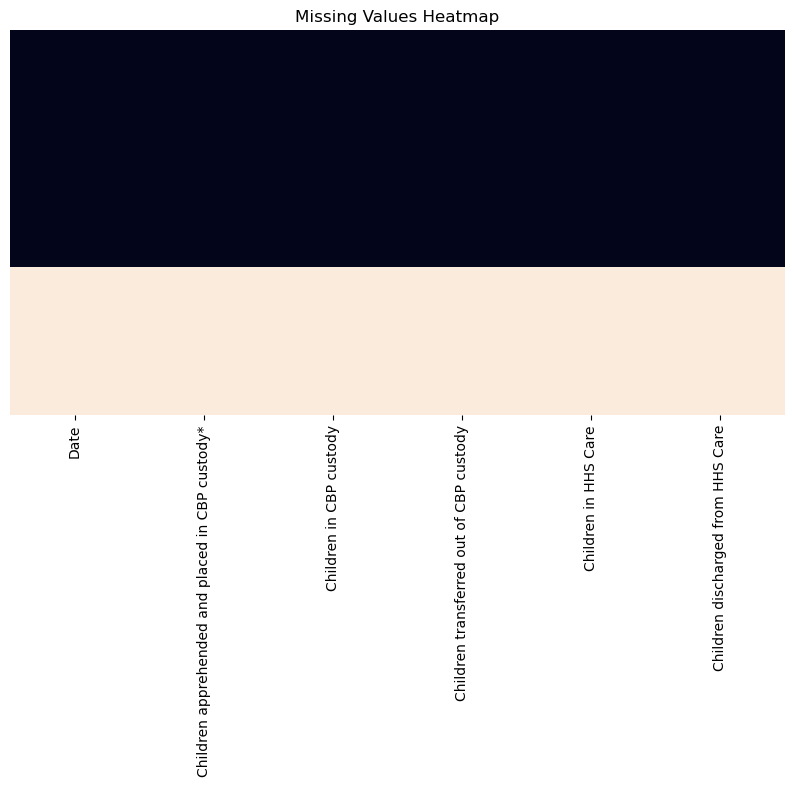

In [15]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.show()

In [16]:
df.duplicated().sum()

449

In [17]:
df = df.dropna(
    how='all'
)

In [18]:
df.shape

(720, 6)

In [19]:
df['Date'] = pd.to_datetime(df['Date'])

In [20]:
df = df.sort_values("Date")

In [21]:
df['Children in HHS Care'].head(20)

719    6,566
718    7,122
717    7,280
716    7,433
715    7,538
714    7,472
713    7,743
712    7,803
711    7,903
710    7,879
709    7,586
708    7,720
707    7,855
706    7,915
705    7,908
704    7,434
703    7,483
702    7,794
701    7,869
700    7,793
Name: Children in HHS Care, dtype: object

In [22]:
df['Children in HHS Care'] = (
    df['Children in HHS Care']
    .str.replace(',', '', regex=False)
)

df['Children in HHS Care'] = pd.to_numeric(
    df['Children in HHS Care'],
    errors='coerce'
)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 720 entries, 719 to 0
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 39.4 KB


In [24]:
df['Month'] = (
    df['Date']
    .dt.to_period('M')
)

In [25]:
df[
[
'Children in CBP custody',
'Children in HHS Care'
]
].describe()

,Children in CBP custody,Children in HHS Care
count,720.000000,720.000000
mean,171.494444,6061.275000
std,126.354965,2833.070109
min,7.000000,1972.000000
25%,36.000000,2467.750000
50%,193.000000,6406.500000
75%,263.250000,8010.250000
max,531.000000,11516.000000


In [26]:
df['Transfer_Efficiency'] = (
    df['Children transferred out of CBP custody']
    /
    df['Children in CBP custody']
)

In [27]:
df['Discharge_Effectiveness'] = (
    df['Children discharged from HHS Care']
    /
    df['Children in HHS Care']
)

In [28]:
df['Discharge_Effectiveness'].describe()

count    720.000000
mean       0.023737
std        0.013310
min        0.000000
25%        0.008616
50%        0.026297
75%        0.032939
max        0.066403
Name: Discharge_Effectiveness, dtype: float64

In [29]:
df['Transfer_to_Discharge_Ratio'] = (
    df['Children transferred out of CBP custody']
    /
    df['Children discharged from HHS Care']
)

In [30]:
df['HHS_Care_Load_Ratio'] = (
    df['Children in HHS Care']
    /
    (
        df['Children in HHS Care']
        +
        df['Children discharged from HHS Care']
    )
)

In [31]:
df['Pipeline_Throughput'] = (
    df['Children discharged from HHS Care']
    /
    (
        df['Children apprehended and placed in CBP custody*']
        +
        df['Children transferred out of CBP custody']
    )
)

In [32]:
df['Transfer_Backlog'] = (
    df['Children in CBP custody']
    -
    df['Children transferred out of CBP custody']
)

In [62]:
df['Stagnation_Flag'] = np.where(
    df['Transfer_Efficiency'] < 0.5,
    1,
    0
)

In [63]:
df['Stagnation_Period'] = (
    df['Stagnation_Flag']
    .rolling(window=7)
    .sum()
)

In [64]:
stagnation_days = df[
    df['Stagnation_Period'] >= 5
]

stagnation_days[
    ['Date',
     'Transfer_Efficiency',
     'Stagnation_Period']
].head()

,Date,Transfer_Efficiency,Stagnation_Period
193,2025-03-06,0.222222,5.0
191,2025-03-10,0.285714,5.0
189,2025-03-12,0.111111,5.0
188,2025-03-13,0.450000,5.0
185,2025-03-18,0.176471,5.0


In [33]:
df['Day_Type'] = np.where(
    df['Date'].dt.dayofweek >= 5,
    'Weekend',
    'Weekday'
)

In [34]:
weekday_weekend = (
    df.groupby('Day_Type')['Transfer_Efficiency']
    .mean()
    .reset_index()
)

weekday_weekend

,Day_Type,Transfer_Efficiency
0,Weekday,0.689020
1,Weekend,0.700083


In [35]:
df['Alert'] = np.where(
    df['Transfer_Efficiency'] < 0.5,
    'Warning',
    'Normal'
)

In [36]:
df['Rolling_Transfer_Efficiency'] = (
    df['Transfer_Efficiency']
    .rolling(7)
    .mean()
)

In [37]:
df['Rolling_Discharge_Effectiveness'] = (
    df['Discharge_Effectiveness']
    .rolling(7)
    .mean()
)

In [38]:
kpi_cols = [

    'Transfer_Efficiency',

    'Discharge_Effectiveness',

    'Transfer_to_Discharge_Ratio',

    'HHS_Care_Load_Ratio',

    'Pipeline_Throughput'

]

In [39]:
df[kpi_cols] = (
    df[kpi_cols]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


In [44]:
df[kpi_cols].describe()

,Transfer_Efficiency,Discharge_Effectiveness,Transfer_to_Discharge_Ratio,HHS_Care_Load_Ratio,Pipeline_Throughput
count,720.000000,720.000000,719.000000,720.000000,720.000000
mean,0.691018,0.023737,0.924850,0.976979,1.072839
std,0.309811,0.013310,1.036666,0.012739,1.316601
min,0.000000,0.000000,0.000000,0.937732,0.000000
25%,0.500000,0.008616,0.490452,0.968112,0.500000
50%,0.704449,0.026297,0.777778,0.974377,0.721051
75%,0.846429,0.032939,1.156233,0.991458,1.148810
max,2.300000,0.066403,22.000000,1.000000,16.000000


In [45]:
print(
    "Average Transfer Efficiency:",
    round(
        df['Transfer_Efficiency'].mean(),
        2
    )
)

print(
    "Average Discharge Effectiveness:",
    round(
        df['Discharge_Effectiveness'].mean(),
        4
    )
)

print(
    "Total Discharges:",
    int(
        df['Children discharged from HHS Care'].sum()
    )
)

Average Transfer Efficiency: 0.69
Average Discharge Effectiveness: 0.0237
Total Discharges: 124853


In [49]:
df.shape

(720, 17)

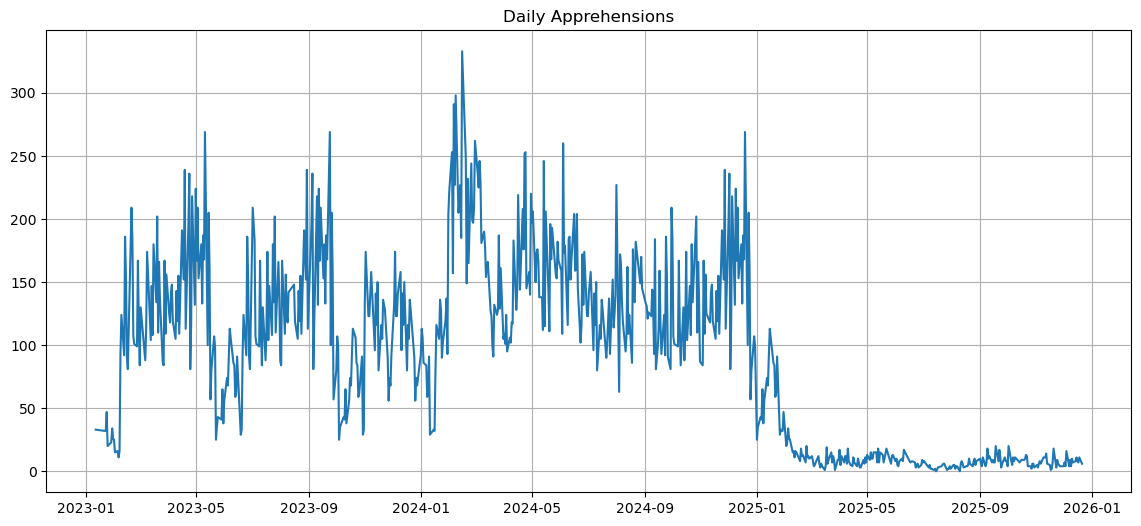

In [50]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Children apprehended and placed in CBP custody*']
)

plt.title(
    "Daily Apprehensions"
)

plt.grid(True)

plt.show()

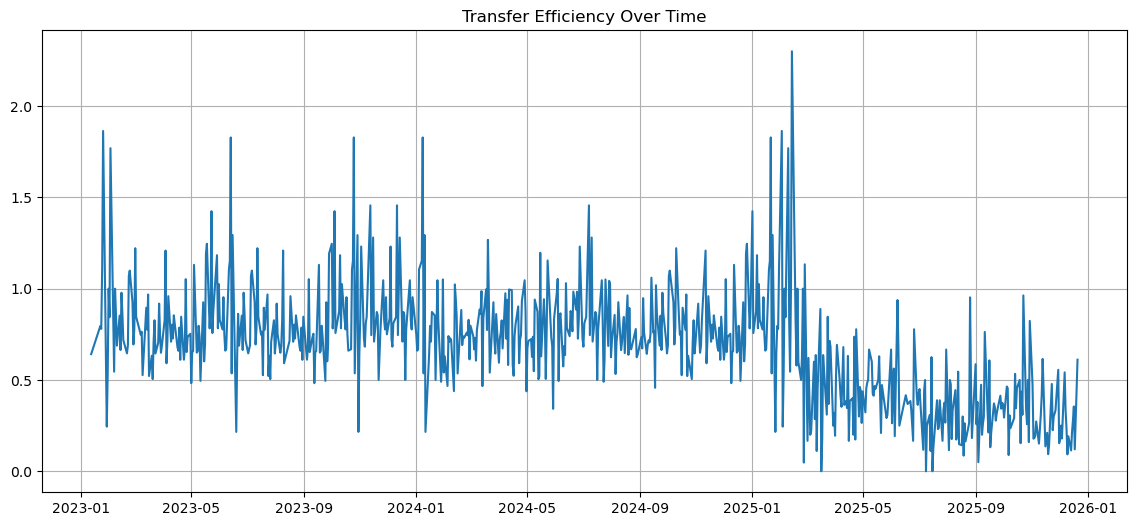

In [51]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Transfer_Efficiency']
)

plt.title(
    "Transfer Efficiency Over Time"
)

plt.grid(True)

plt.show()

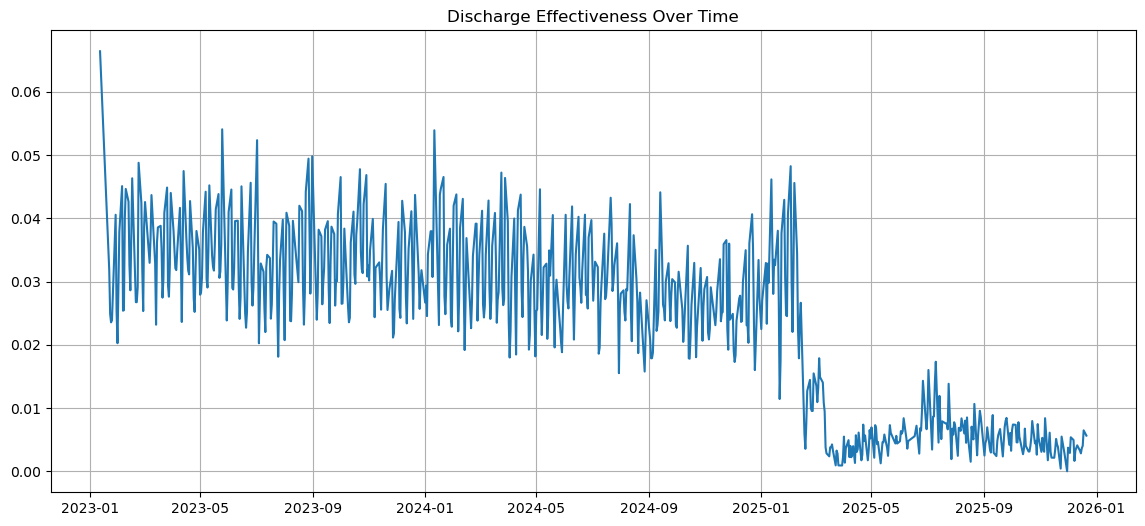

In [52]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Discharge_Effectiveness']
)

plt.title(
    "Discharge Effectiveness Over Time"
)

plt.grid(True)

plt.show()

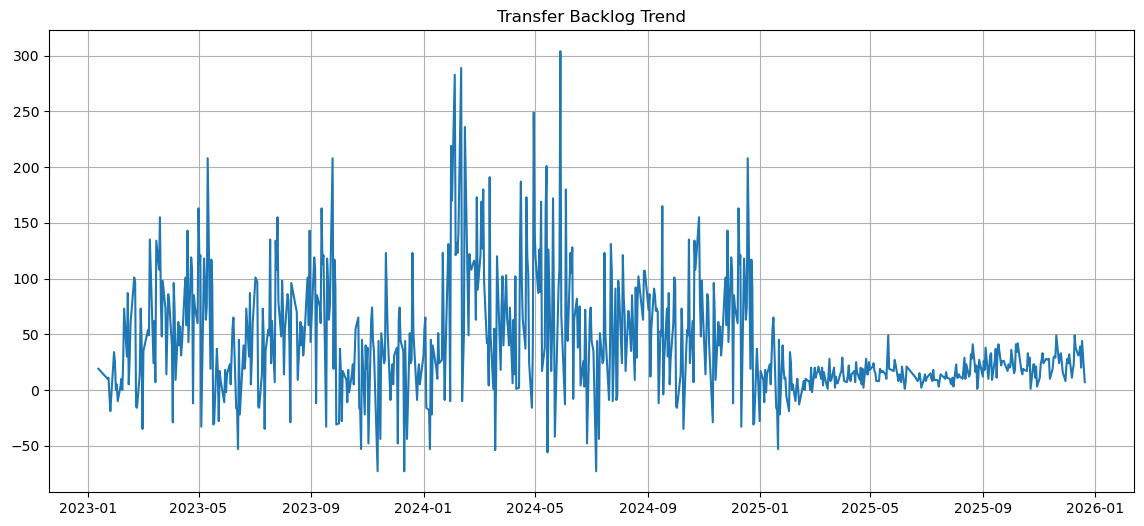

In [53]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Transfer_Backlog']
)

plt.title(
    "Transfer Backlog Trend"
)

plt.grid(True)

plt.show()

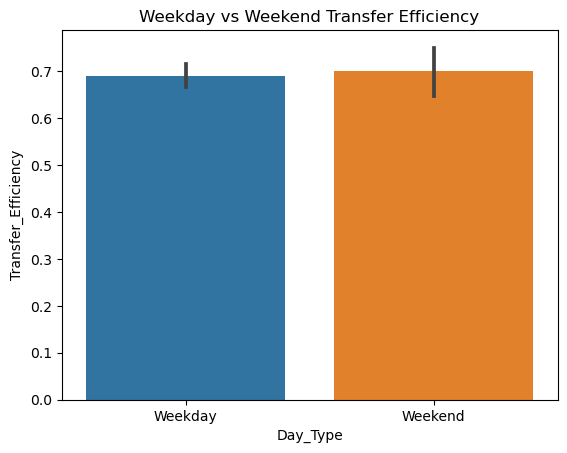

In [54]:
sns.barplot(
    data=df,
    x='Day_Type',
    y='Transfer_Efficiency'
)

plt.title(
    "Weekday vs Weekend Transfer Efficiency"
)

plt.show()

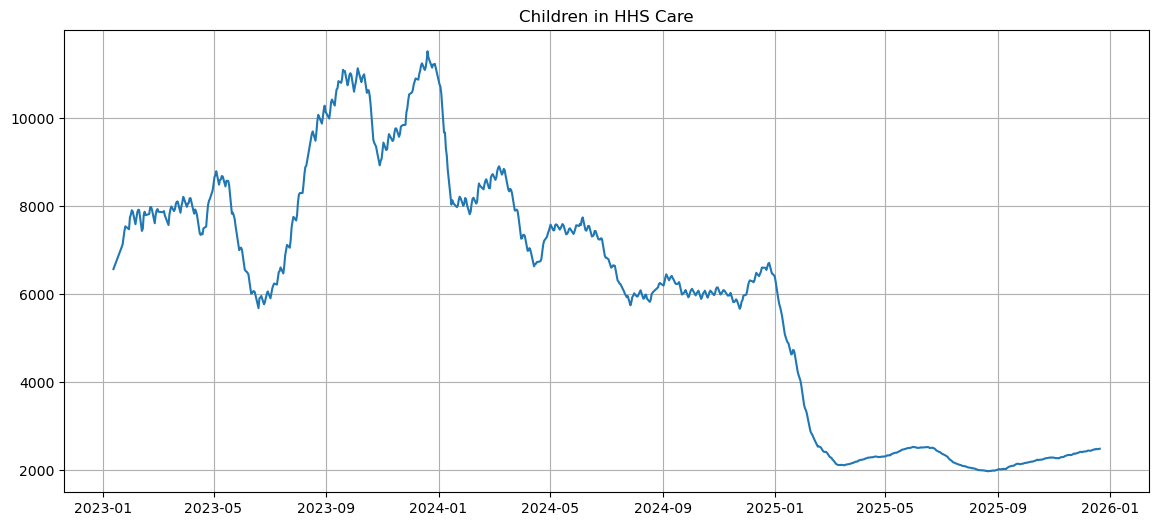

In [55]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Children in HHS Care']
)

plt.title(
    "Children in HHS Care"
)

plt.grid(True)

plt.show()

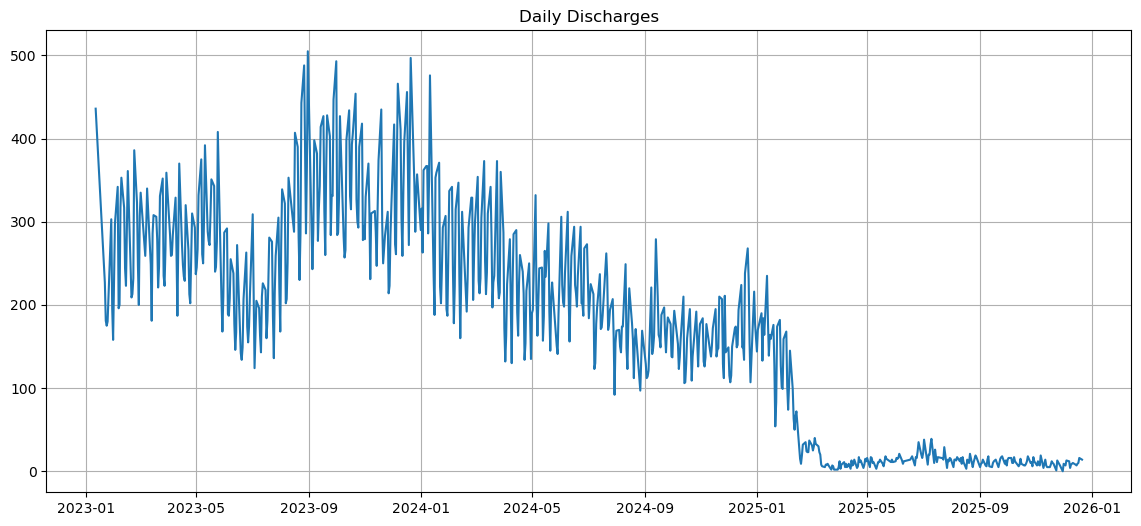

In [56]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Children discharged from HHS Care']
)

plt.title(
    "Daily Discharges"
)

plt.grid(True)

plt.show()

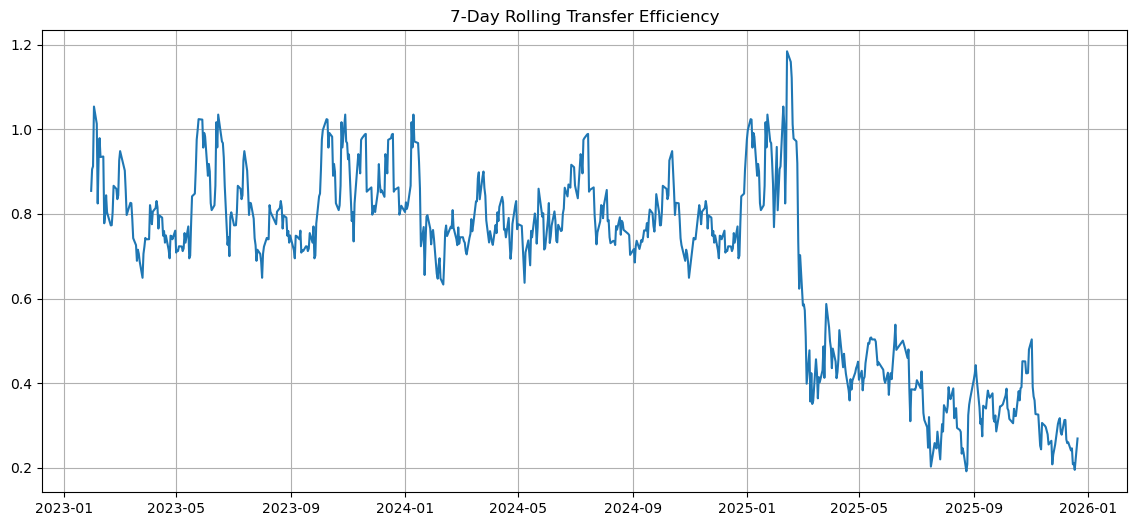

In [57]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Rolling_Transfer_Efficiency']
)

plt.title(
    "7-Day Rolling Transfer Efficiency"
)

plt.grid(True)

plt.show()

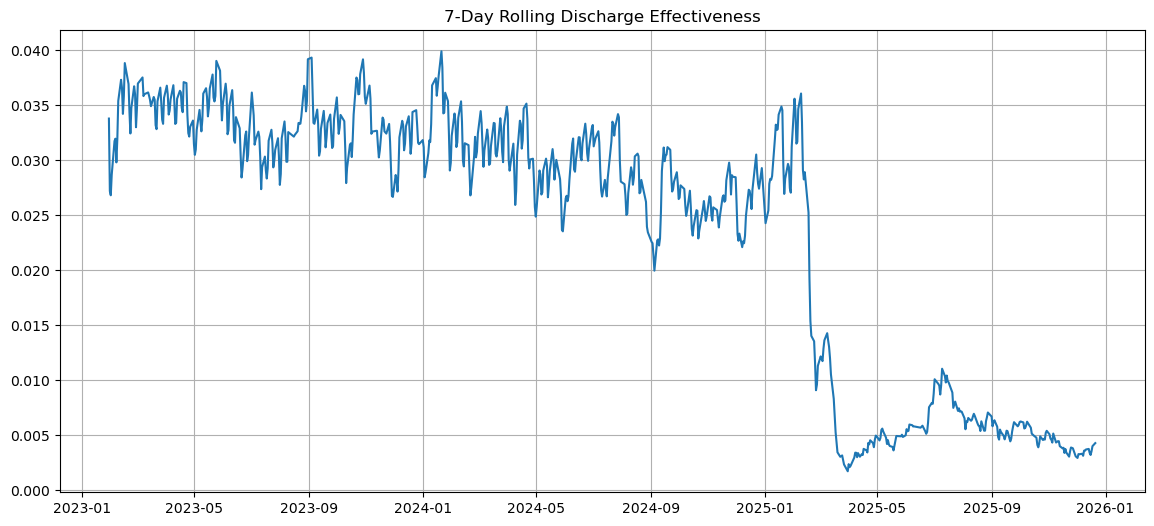

In [58]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Date'],
    df['Rolling_Discharge_Effectiveness']
)

plt.title(
    "7-Day Rolling Discharge Effectiveness"
)

plt.grid(True)

plt.show()

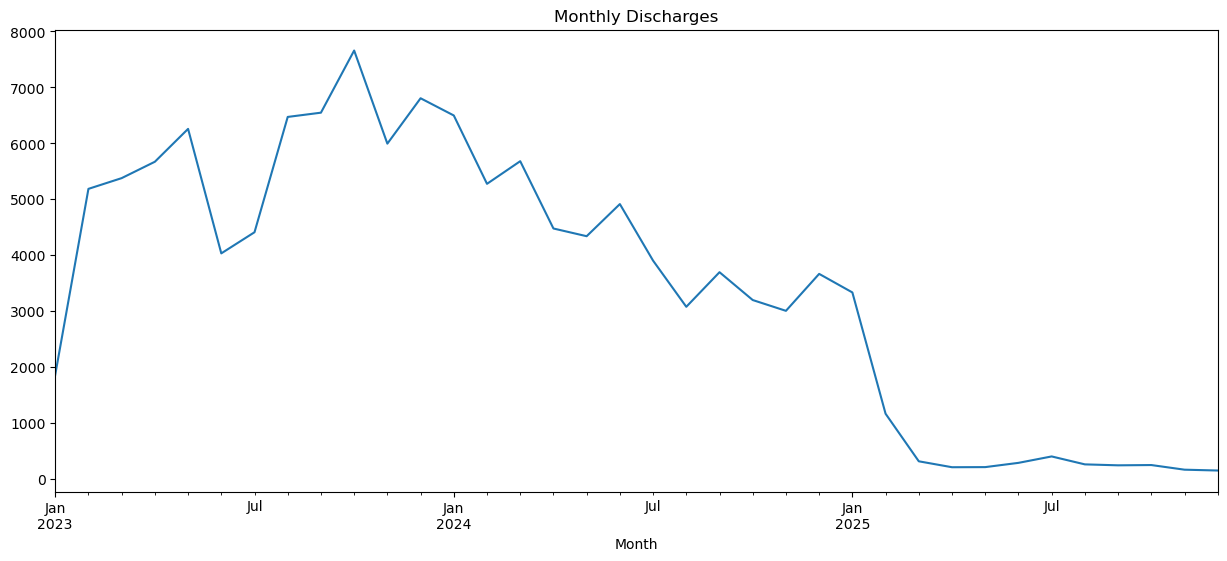

In [59]:
monthly = df.groupby(
    'Month'
)[
    'Children discharged from HHS Care'
].sum()

monthly.plot(
    figsize=(15,6)
)

plt.title(
    "Monthly Discharges"
)

plt.show()

In [60]:
df['Alert'].value_counts()

Alert
Normal     545
Warning    175
Name: count, dtype: int64

In [65]:
df.to_csv(
    "../data/cleaned_uac.csv",
    index=False
)